In [1]:
import os
import warnings

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%pip install librosa

# audio
import librosa
import librosa.display
import soundfile as sf

from scipy.signal import correlate

# classical ML
from sklearn.model_selection import (
    train_test_split,  # kept for compatibility; we will use group-aware splitters below
    StratifiedKFold,  # kept for compatibility; we will use StratifiedGroupKFold below
    StratifiedGroupKFold,
    GroupShuffleSplit,
    RandomizedSearchCV,
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc,
)
from sklearn.preprocessing import LabelEncoder, label_binarize

%pip install xgboost

from xgboost import XGBClassifier

%pip install catboost

try:
    from catboost import CatBoostClassifier
except ImportError:
    CatBoostClassifier = None
    print("Install CatBoost for full results: pip install catboost")

# deep learning (Keras 3 / TF)
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    MaxPooling2D,
    UpSampling2D,
    Concatenate,
    GlobalAveragePooling2D,
    Dense,
    Dropout,
    BatchNormalization,
    Activation,
)
from tensorflow.keras.preprocessing.sequence import pad_sequences

warnings.filterwarnings("ignore", category=UserWarning)


## Importing the dataset from Kaggle  ##
This dataset contains 2500 wav files, 500 each for 5 different moods.The dataset is from kaggle.

In [2]:
#!pip install kaggle catboost


In [3]:
#!kaggle datasets download -d auliayasmin/music-mood-classification


In [4]:
#!unzip music-mood-classification.zip


## Notebook structure

1. **Setup** — imports and configuration (single place).
2. **Data** — tabular features and mel spectrograms are each built **once**; all models reuse these arrays (no duplicated loading loops).
3. **Classical models** — `RandomizedSearchCV` hyperparameter search, then evaluation across several **train/test data seeds** and **model random seeds** (mean ± std). Includes Random Forest, XGBoost (multiclass), **CatBoost**, **one-vs-rest XGBoost** (five binary models), **ROC** (one-vs-rest), and **5×5 confusion matrices**.
4. **Deep learning** — **U-Net–style** 2D model on padded mel maps; two training seeds for a variability summary.

Audio is handled with **librosa**.

### Tabular features (MFCC / chroma / contrast / ZCR)

These vectors feed tree ensembles (Random Forest, XGBoost, CatBoost). The same `X_tabular` and `y_tabular` are reused in every classical-model cell below.

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
# --- shared configuration (paths, sampling, reproducibility) ---
# DATASET_PATH = "dataset"
DATASET_PATH = "/content/drive/MyDrive/thesis/dataset"
ARTIFACTS_DIR = "/content/drive/MyDrive/thesis/artifacts"
os.makedirs(ARTIFACTS_DIR, exist_ok=True)
GROUPING_ARTIFACT_PATH = os.path.join(ARTIFACTS_DIR, "kaggle_overlap_groups.joblib")

MOODS = ["aggressive", "dramatic", "happy", "romantic", "sad"]
SAMPLES_PER_CLASS = 500  # increase if you have compute budget (full folder has 500 each)
N_MELS = 128

# Multiple train/test splits and model initialisations (report mean ± std)
DATA_SEEDS = (0, 17, 42, 99, 123)
MODEL_SEEDS = (7, 42, 99)

# Grouping config: detect if consecutive 5s clips are overlapping slices of the same longer track.
# We compare the tail of clip i to the head of clip i+1 and treat them as the same song if similarity is high.
GROUP_TAIL_SEC = 4
GROUP_HEAD_SEC = 4
GROUP_MAX_LAG_SEC = 0.3  # allow small misalignment in samples
GROUP_CORR_THRESHOLD = 0.4  # increase to be stricter (fewer merges), decrease to be more permissive

TUNING_RANDOM_STATE = 42
TUNING_CV = StratifiedGroupKFold(n_splits=3, shuffle=True, random_state=TUNING_RANDOM_STATE)

features_tabular = []
labels = []
file_paths_tabular = []
groups_tabular = []


In [7]:
# --- detect overlapping slices and assign group ids ("same-song" groups) ---

def _read_mono_segment(path: str, start_frame: int, n_frames: int):
    """Read a mono segment using soundfile; returns float32 array."""
    with sf.SoundFile(path) as f:
        sr = int(f.samplerate)
        start_frame = int(max(0, min(start_frame, len(f))))
        f.seek(start_frame)
        x = f.read(int(n_frames), dtype="float32", always_2d=True)
    x = np.mean(x, axis=1)  # downmix
    return x, sr


def _tail_head_similarity(prev_path: str, next_path: str, tail_sec: float, head_sec: float, max_lag_sec: float):
    """Return max normalized cross-correlation between prev tail and next head within ±max_lag."""
    try:
        with sf.SoundFile(prev_path) as fprev:
            sr_prev = int(fprev.samplerate)
            n_prev = len(fprev)
        with sf.SoundFile(next_path) as fnext:
            sr_next = int(fnext.samplerate)

        # If sample rates differ, fall back to librosa-based resampling for the small segments.
        if sr_prev != sr_next:
            # read ~1s segments then resample
            tail, _ = _read_mono_segment(prev_path, max(0, n_prev - int(tail_sec * sr_prev)), int(tail_sec * sr_prev))
            head, _ = _read_mono_segment(next_path, 0, int(head_sec * sr_next))
            head = librosa.resample(head, orig_sr=sr_next, target_sr=sr_prev)
            sr = sr_prev
        else:
            sr = sr_prev
            tail, _ = _read_mono_segment(prev_path, max(0, n_prev - int(tail_sec * sr)), int(tail_sec * sr))
            head, _ = _read_mono_segment(next_path, 0, int(head_sec * sr))

        if len(tail) < 128 or len(head) < 128:
            return 0.0

        # Normalize (guard against near-silence)
        tail = tail - float(np.mean(tail))
        head = head - float(np.mean(head))
        nt = float(np.linalg.norm(tail))
        nh = float(np.linalg.norm(head))
        if nt < 1e-6 or nh < 1e-6:
            return 0.0
        tail = tail / nt
        head = head / nh

        # Cross-correlation (FFT) and restrict lag range
        c = correlate(tail, head, mode="full", method="fft")
        mid = len(c) // 2
        max_lag = int(max_lag_sec * sr)
        lo = max(0, mid - max_lag)
        hi = min(len(c), mid + max_lag + 1)
        return float(np.max(c[lo:hi]))
    except Exception as e:
        print(f"Similarity error for {prev_path} -> {next_path}: {e}")
        return 0.0


def _natural_wav_sort_key(filename: str):
    stem = os.path.splitext(filename)[0]
    return (0, int(stem)) if stem.isdigit() else (1, stem)


all_paths = []
all_labels = []
all_groups = []

breakpoints = {}  # mood -> list of dicts

next_group_id = 0
for mood in MOODS:
    mood_folder = os.path.join(DATASET_PATH, mood)
    files = [fn for fn in os.listdir(mood_folder) if fn.lower().endswith(".wav")]
    files = sorted(files, key=_natural_wav_sort_key)[:SAMPLES_PER_CLASS]

    mood_paths = [os.path.join(mood_folder, fn) for fn in files]
    mood_groups = []
    mood_breaks = []

    if len(mood_paths) == 0:
        raise FileNotFoundError(f"No .wav files found for mood '{mood}' in {mood_folder}")

    current_gid = next_group_id
    mood_groups.append(current_gid)

    for i in range(1, len(mood_paths)):
        prev_fp = mood_paths[i - 1]
        next_fp = mood_paths[i]
        sim = _tail_head_similarity(
            prev_fp,
            next_fp,
            tail_sec=GROUP_TAIL_SEC,
            head_sec=GROUP_HEAD_SEC,
            max_lag_sec=GROUP_MAX_LAG_SEC,
        )
        same_song = sim >= GROUP_CORR_THRESHOLD
        if not same_song:
            # breakpoint before i
            mood_breaks.append(
                {
                    "break_at_index": i,
                    "prev_file": os.path.basename(prev_fp),
                    "next_file": os.path.basename(next_fp),
                    "similarity": float(sim),
                    "ended_group_id": int(current_gid),
                }
            )
            next_group_id += 1
            current_gid = next_group_id
        mood_groups.append(current_gid)

    # reserve group ids for next mood (ensure global uniqueness)
    next_group_id = int(max(mood_groups)) + 1

    breakpoints[mood] = mood_breaks

    all_paths.extend(mood_paths)
    all_labels.extend([mood] * len(mood_paths))
    all_groups.extend(mood_groups)

# Print breakpoints for sanity checking
print("\n--- Detected same-song grouping breakpoints (per mood) ---")
for mood in MOODS:
    br = breakpoints[mood]
    n_files = sum(1 for lbl in all_labels if lbl == mood)
    n_groups = len(set(g for g, lbl in zip(all_groups, all_labels) if lbl == mood))
    print(f"{mood}: files={n_files}, groups={n_groups}, breaks={len(br)}")
    # show first ~15 breakpoints for manual inspection
    for row in br[:15]:
        print(
            f"  break@{row['break_at_index']:>3}  sim={row['similarity']:.3f}  "
            f"{row['prev_file']} -> {row['next_file']} (ended group {row['ended_group_id']})"
        )
    if len(br) > 15:
        print(f"  ... {len(br)-15} more breakpoints not shown")

all_groups = np.asarray(all_groups, dtype=int)

# Save grouping results so other notebooks can reuse the exact same grouping/breakpoints
# without re-running overlap detection.
grouping_bundle = {
    "all_paths": all_paths,
    "all_labels": all_labels,
    "all_groups": all_groups,
    "breakpoints": breakpoints,
    "config": {
        "DATASET_PATH": DATASET_PATH,
        "MOODS": MOODS,
        "SAMPLES_PER_CLASS": SAMPLES_PER_CLASS,
        "GROUP_TAIL_SEC": GROUP_TAIL_SEC,
        "GROUP_HEAD_SEC": GROUP_HEAD_SEC,
        "GROUP_MAX_LAG_SEC": GROUP_MAX_LAG_SEC,
        "GROUP_CORR_THRESHOLD": GROUP_CORR_THRESHOLD,
    },
}
joblib.dump(grouping_bundle, GROUPING_ARTIFACT_PATH)
print(f"Saved grouping artifact: {GROUPING_ARTIFACT_PATH}")



--- Detected same-song grouping breakpoints (per mood) ---
aggressive: files=500, groups=24, breaks=23
  break@ 18  sim=0.078  6778.wav -> 6799.wav (ended group 0)
  break@ 77  sim=0.051  6857.wav -> 6858.wav (ended group 1)
  break@105  sim=0.045  6885.wav -> 6909.wav (ended group 2)
  break@123  sim=0.084  6926.wav -> 6927.wav (ended group 3)
  break@144  sim=0.077  6947.wav -> 6952.wav (ended group 4)
  break@159  sim=0.037  6966.wav -> 6967.wav (ended group 5)
  break@180  sim=0.054  6987.wav -> 6988.wav (ended group 6)
  break@199  sim=0.038  7006.wav -> 7023.wav (ended group 7)
  break@204  sim=0.041  7027.wav -> 7100.wav (ended group 8)
  break@210  sim=0.009  7105.wav -> 7121.wav (ended group 9)
  break@254  sim=0.054  7164.wav -> 7165.wav (ended group 10)
  break@274  sim=0.045  7184.wav -> 7185.wav (ended group 11)
  break@293  sim=0.051  7203.wav -> 7204.wav (ended group 12)
  break@316  sim=0.063  7226.wav -> 7331.wav (ended group 13)
  break@330  sim=0.070  7344.wav -> 73

In [8]:
def extract_features(file_path):
    """MFCC, chroma, spectral contrast, and ZCR summaries for tree-based models."""
    try:
        y, sr = librosa.load(file_path, sr=None)
        mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
        mfcc_mean = np.mean(mfcc.T, axis=0)
        chroma = librosa.feature.chroma_stft(y=y, sr=sr)
        chroma_mean = np.mean(chroma.T, axis=0)
        contrast = librosa.feature.spectral_contrast(y=y, sr=sr)
        contrast_mean = np.mean(contrast.T, axis=0)
        zcr = librosa.feature.zero_crossing_rate(y)
        zcr_mean = np.mean(zcr)
        return np.hstack((mfcc_mean, chroma_mean, contrast_mean, zcr_mean))
    except Exception as e:
        print(f"Error processing {file_path}: {e}")
        return None


In [9]:
# Build tabular dataset once for all classical models
# IMPORTANT: we use the precomputed (path, label, group_id) lists so that later splits can be group-aware.
for fp, mood, gid in zip(all_paths, all_labels, all_groups):
    vec = extract_features(fp)
    if vec is not None:
        features_tabular.append(vec)
        labels.append(mood)
        file_paths_tabular.append(fp)
        groups_tabular.append(int(gid))

X_tabular = np.asarray(features_tabular, dtype=np.float32)
y_labels = np.asarray(labels)
groups_tabular = np.asarray(groups_tabular, dtype=int)
print("Tabular shape:", X_tabular.shape, "labels:", y_labels.shape, "groups:", groups_tabular.shape)
print("Unique groups:", len(np.unique(groups_tabular)))


Tabular shape: (2500, 33) labels: (2500,) groups: (2500,)
Unique groups: 128


In [10]:
print("First rows (features):", X_tabular[:2])
print("First labels:", y_labels[:5])


First rows (features): [[-1.31995956e+02  2.06185318e+02 -4.75330086e+01 -1.09593649e+01
   1.13534660e+01  1.54600401e+01  8.31403911e-01  1.38233986e+01
   3.89158535e+00  6.02401638e+00  2.21398687e+00  8.09124470e+00
   4.81216478e+00  6.98612094e-01  6.07390642e-01  5.79352140e-01
   6.17072940e-01  6.25317156e-01  7.29506969e-01  6.38447106e-01
   5.45594811e-01  5.89931190e-01  5.66412807e-01  5.37877202e-01
   5.48018754e-01  1.18697462e+01  6.95737839e+00  1.24280558e+01
   1.24634237e+01  1.50916815e+01  2.12540627e+01  3.67181168e+01
   4.06383686e-02]
 [-1.60421234e+02  2.26486557e+02 -4.29674530e+01 -1.62894993e+01
   1.80271130e+01  9.20457935e+00  4.87327099e+00  1.22551680e+01
   4.40152359e+00  3.63648415e+00  3.75024056e+00  6.74352217e+00
   5.85993576e+00  7.04383016e-01  5.98969519e-01  5.93531013e-01
   6.51379108e-01  6.36168838e-01  7.20185935e-01  6.16505861e-01
   5.47048032e-01  5.85603416e-01  5.61079502e-01  5.35898387e-01
   5.61423719e-01  1.12722435e+01 

In [11]:
label_encoder = LabelEncoder()
y_tabular = label_encoder.fit_transform(y_labels)
class_names = label_encoder.classes_
n_classes = len(class_names)
print("Classes (label order):", list(class_names))


Classes (label order): [np.str_('aggressive'), np.str_('dramatic'), np.str_('happy'), np.str_('romantic'), np.str_('sad')]


### Mel spectrograms (shared tensor pipeline for deep learning)


In [12]:
def extract_mel_spectrogram(file_path, n_mels=N_MELS):
    """Mel spectrogram as (time, n_mels) in dB scale."""
    try:
        y, sr = librosa.load(file_path, sr=None)
        mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=n_mels)
        mel_db = librosa.power_to_db(mel, ref=np.max)
        return mel_db.T
    except Exception as e:
        print(f"Error processing {file_path}: {e}")
        return None


mel_specs = []
mel_label_indices = []
groups_mel = []

# Use the same (path, label, group_id) ordering as the tabular pipeline.
# This ensures deep learning train/test splits can also be group-aware.
per_mood_ok = {m: 0 for m in MOODS}
for fp, mood, gid in zip(all_paths, all_labels, all_groups):
    spec = extract_mel_spectrogram(fp)
    if spec is not None:
        mel_specs.append(spec)
        mel_label_indices.append(int(MOODS.index(mood)))
        groups_mel.append(int(gid))
        per_mood_ok[mood] += 1

for m in MOODS:
    print(f"Mel spectrograms loaded for {m}: {per_mood_ok[m]} files")

y_mel = np.asarray(mel_label_indices, dtype=np.int32)
groups_mel = np.asarray(groups_mel, dtype=int)
print("Total mel samples:", len(mel_specs), "labels:", y_mel.shape, "groups:", groups_mel.shape)


Mel spectrograms loaded for aggressive: 500 files
Mel spectrograms loaded for dramatic: 500 files
Mel spectrograms loaded for happy: 500 files
Mel spectrograms loaded for romantic: 500 files
Mel spectrograms loaded for sad: 500 files
Total mel samples: 2500 labels: (2500,) groups: (2500,)


### Visual inspection of mel spectrograms


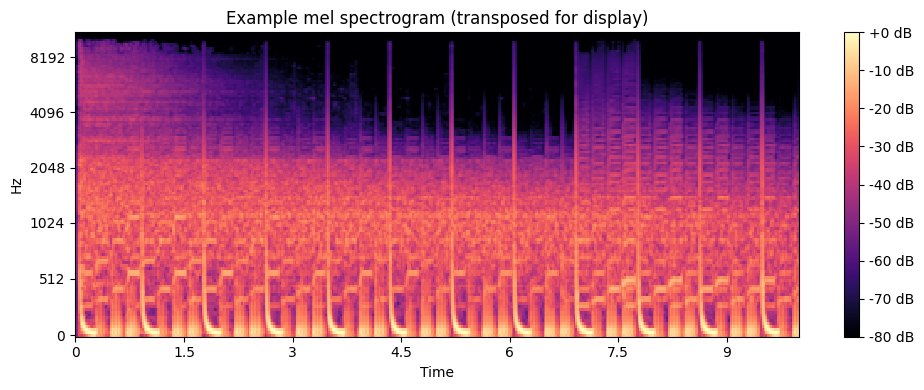

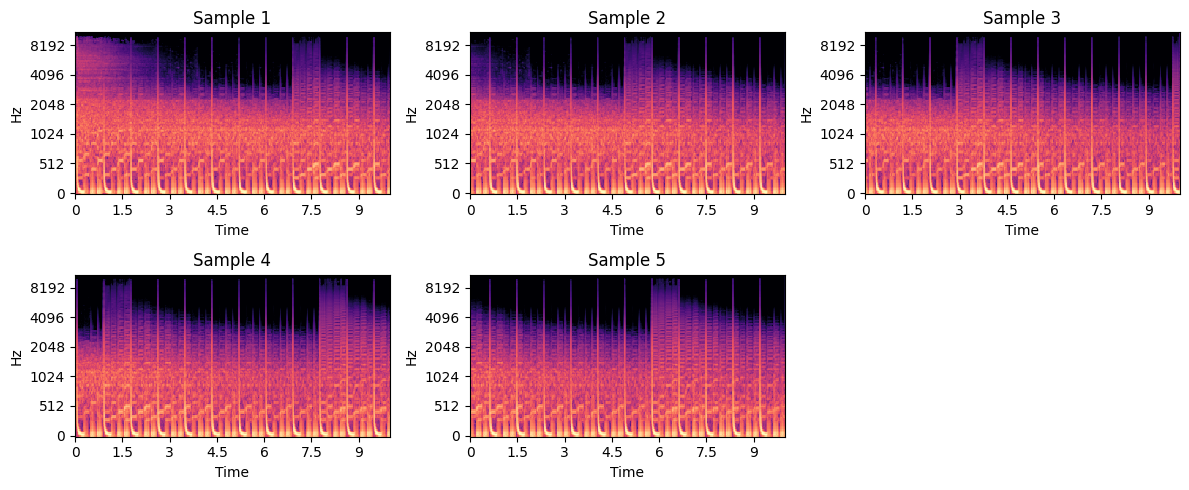

In [13]:
# Quick visual check (same files as tabular pipeline)
example = mel_specs[0]
plt.figure(figsize=(10, 4))
librosa.display.specshow(example.T, x_axis="time", y_axis="mel", sr=22050, hop_length=512)
plt.colorbar(format="%+2.0f dB")
plt.title("Example mel spectrogram (transposed for display)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
for i in range(min(5, len(mel_specs))):
    plt.subplot(2, 3, i + 1)
    librosa.display.specshow(mel_specs[i].T, x_axis="time", y_axis="mel", sr=22050, hop_length=512)
    plt.title(f"Sample {i + 1}")
plt.tight_layout()
plt.show()


## Classical models (Random Forest, XGBoost, CatBoost)

Tabular features are built **once** above. Here we (i) tune hyperparameters with **RandomizedSearchCV** on stratified CV, (ii) re-fit on several **train/test splits** (`DATA_SEEDS`) and **model random seeds** (`MODEL_SEEDS`), and report **mean ± standard deviation** of test accuracy. **ROC** (one-vs-rest) and **5×5 confusion matrices** use a single reference hold-out (`reference_data_seed=42`) with the tuned hyperparameters for readability.


In [14]:
# ----- 1) Hyperparameter search (one pass on full data, CV only — no fixed test set) -----

# We must avoid leakage between overlapping 5s clips.
# Therefore, we split by "group_id" (same-song groups), so train and test contain disjoint songs.

def _group_train_test_indices(seed: int, test_size: float = 0.2):
    splitter = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=int(seed))
    tr_idx, te_idx = next(splitter.split(X_tabular, y_tabular, groups=groups_tabular))
    return tr_idx, te_idx


def summarize_multiseed(clf_factory, name):
    """clf_factory(ms) -> unfitted sklearn-compatible estimator with random_state set."""
    scores = []
    for ds in DATA_SEEDS:
        tr_idx, te_idx = _group_train_test_indices(ds, test_size=0.2)
        X_tr, X_te = X_tabular[tr_idx], X_tabular[te_idx]
        y_tr, y_te = y_tabular[tr_idx], y_tabular[te_idx]
        for ms in MODEL_SEEDS:
            clf = clf_factory(ms)
            clf.fit(X_tr, y_tr)
            scores.append(accuracy_score(y_te, clf.predict(X_te)))
    scores = np.asarray(scores, dtype=np.float64)
    print(
        f"{name}: mean acc = {scores.mean():.4f}, std = {scores.std(ddof=1):.4f} "
        f"(over {len(scores)} runs: |DATA_SEEDS|×|MODEL_SEEDS|; group-aware split)"
    )
    return scores


# Random Forest
rf_param_dist = {
    "n_estimators": [100, 200, 350],
    "max_depth": [None, 12, 20, 28],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"],
}
rf_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=TUNING_RANDOM_STATE),
    rf_param_dist,
    n_iter=18,
    cv=TUNING_CV,
    random_state=TUNING_RANDOM_STATE,
    n_jobs=-1,
    verbose=0,
)
rf_search.fit(X_tabular, y_tabular, groups=groups_tabular)
print("Best RF params:", rf_search.best_params_)

rf_scores = summarize_multiseed(
    lambda ms: RandomForestClassifier(**rf_search.best_params_, random_state=ms),
    "RandomForest (tuned)",
)

# XGBoost (multiclass)
xgb_param_dist = {
    "n_estimators": [150, 300, 500],
    "max_depth": [3, 5, 7, 9],
    "learning_rate": [0.02, 0.05, 0.1, 0.2],
    "subsample": [0.7, 0.85, 1.0],
    "colsample_bytree": [0.7, 0.85, 1.0],
    "min_child_weight": [1, 3, 5],
}
xgb_base = XGBClassifier(
    objective="multi:softprob",
    num_class=int(n_classes),
    eval_metric="mlogloss",
    tree_method="hist",
    random_state=TUNING_RANDOM_STATE,
)
xgb_search = RandomizedSearchCV(
    xgb_base,
    xgb_param_dist,
    n_iter=18,
    cv=TUNING_CV,
    random_state=TUNING_RANDOM_STATE,
    n_jobs=-1,
    verbose=0,
)
xgb_search.fit(X_tabular, y_tabular, groups=groups_tabular)
print("Best XGB (multiclass) params:", xgb_search.best_params_)

xgb_scores = summarize_multiseed(
    lambda ms: XGBClassifier(
        **xgb_search.best_params_,
        objective="multi:softprob",
        num_class=int(n_classes),
        eval_metric="mlogloss",
        tree_method="hist",
        random_state=ms,
    ),
    "XGBoost multiclass (tuned)",
)

# CatBoost — strong default for tabular / ordered targets; here labels are still numeric classes
if CatBoostClassifier is None:
    cb_search = None
    print("Skipping CatBoost (package not installed).")
else:
    cb_param_dist = {
        "depth": [4, 6, 8, 10],
        "learning_rate": [0.03, 0.07, 0.12],
        "l2_leaf_reg": [1, 3, 5, 9],
        "iterations": [250, 400, 600],
    }
    cb_base = CatBoostClassifier(
        loss_function="MultiClass",
        classes_count=int(n_classes),
        verbose=False,
        random_seed=TUNING_RANDOM_STATE,
        allow_writing_files=False,
    )
    cb_search = RandomizedSearchCV(
        cb_base,
        cb_param_dist,
        n_iter=14,
        cv=TUNING_CV,
        random_state=TUNING_RANDOM_STATE,
        n_jobs=1,
        verbose=0,
    )
    cb_search.fit(X_tabular, y_tabular, groups=groups_tabular)
    print("Best CatBoost params:", cb_search.best_params_)

    def cat_factory(ms):
        return CatBoostClassifier(
            **cb_search.best_params_,
            loss_function="MultiClass",
            classes_count=int(n_classes),
            verbose=False,
            random_seed=int(ms),
            allow_writing_files=False,
        )

    cb_scores = summarize_multiseed(cat_factory, "CatBoost (tuned)")

# Reference split for plots / reports (group-aware)
REF_SEED = 42
ref_tr_idx, ref_te_idx = _group_train_test_indices(REF_SEED, test_size=0.2)
X_ref_tr, X_ref_te = X_tabular[ref_tr_idx], X_tabular[ref_te_idx]
y_ref_tr, y_ref_te = y_tabular[ref_tr_idx], y_tabular[ref_te_idx]

rf_ref = RandomForestClassifier(**rf_search.best_params_, random_state=REF_SEED)
rf_ref.fit(X_ref_tr, y_ref_tr)

xgb_ref = XGBClassifier(
    **xgb_search.best_params_,
    objective="multi:softprob",
    num_class=int(n_classes),
    eval_metric="mlogloss",
    tree_method="hist",
    random_state=REF_SEED,
)
xgb_ref.fit(X_ref_tr, y_ref_tr)

if CatBoostClassifier is not None:
    cb_ref = CatBoostClassifier(
        **cb_search.best_params_,
        loss_function="MultiClass",
        classes_count=int(n_classes),
        verbose=False,
        random_seed=REF_SEED,
        allow_writing_files=False,
    )
    cb_ref.fit(X_ref_tr, y_ref_tr)

print("\nReference split (seed=42) — classification report (Random Forest):")
print(classification_report(y_ref_te, rf_ref.predict(X_ref_te), target_names=class_names))


Best RF params: {'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': 28}
RandomForest (tuned): mean acc = 0.4275, std = 0.0503 (over 15 runs: |DATA_SEEDS|×|MODEL_SEEDS|; group-aware split)
Best XGB (multiclass) params: {'subsample': 0.85, 'n_estimators': 300, 'min_child_weight': 5, 'max_depth': 3, 'learning_rate': 0.2, 'colsample_bytree': 0.7}
XGBoost multiclass (tuned): mean acc = 0.3963, std = 0.0617 (over 15 runs: |DATA_SEEDS|×|MODEL_SEEDS|; group-aware split)
Best CatBoost params: {'learning_rate': 0.03, 'l2_leaf_reg': 5, 'iterations': 400, 'depth': 4}
CatBoost (tuned): mean acc = 0.4288, std = 0.0566 (over 15 runs: |DATA_SEEDS|×|MODEL_SEEDS|; group-aware split)

Reference split (seed=42) — classification report (Random Forest):
              precision    recall  f1-score   support

  aggressive       0.93      0.89      0.91       112
    dramatic       0.58      0.28      0.38       131
       happy       0.53      0.59      0.

In [15]:
# ----- One-vs-rest: five separate XGBoost models (binary), ensemble by argmax of P(class) -----

def build_binary_xgb(ms):
    return XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        n_estimators=int(xgb_search.best_params_["n_estimators"]),
        max_depth=int(xgb_search.best_params_["max_depth"]),
        learning_rate=float(xgb_search.best_params_["learning_rate"]),
        subsample=float(xgb_search.best_params_["subsample"]),
        colsample_bytree=float(xgb_search.best_params_["colsample_bytree"]),
        min_child_weight=int(xgb_search.best_params_["min_child_weight"]),
        tree_method="hist",
        random_state=int(ms),
    )


ovr_scores = []
for ds in DATA_SEEDS:
    tr_idx, te_idx = _group_train_test_indices(ds, test_size=0.2)
    X_tr, X_te = X_tabular[tr_idx], X_tabular[te_idx]
    y_tr, y_te = y_tabular[tr_idx], y_tabular[te_idx]
    for ms in MODEL_SEEDS:
        prob_cols = []
        for k in range(n_classes):
            y_bin = (y_tr == k).astype(np.int32)
            m = build_binary_xgb(ms)
            m.fit(X_tr, y_bin)
            prob_cols.append(m.predict_proba(X_te)[:, 1])
        P = np.column_stack(prob_cols)
        pred = np.argmax(P, axis=1)
        ovr_scores.append(accuracy_score(y_te, pred))

ovr_scores = np.asarray(ovr_scores, dtype=np.float64)
print(
    "XGBoost OvR (5 binary models, argmax): "
    f"mean acc = {ovr_scores.mean():.4f}, std = {ovr_scores.std(ddof=1):.4f}"
)

# Fit OvR on reference split for ROC / confusion alongside multiclass models
ovr_prob_cols = []
for k in range(n_classes):
    y_bin = (y_ref_tr == k).astype(np.int32)
    mk = build_binary_xgb(REF_SEED)
    mk.fit(X_ref_tr, y_bin)
    ovr_prob_cols.append(mk.predict_proba(X_ref_te)[:, 1])
P_ovr = np.column_stack(ovr_prob_cols)
# renormalise rows so they sum to 1 (optional, helps interpretation)
P_ovr = P_ovr / P_ovr.sum(axis=1, keepdims=True)
y_ovr_pred = np.argmax(P_ovr, axis=1)
print("OvR reference accuracy:", accuracy_score(y_ref_te, y_ovr_pred))


XGBoost OvR (5 binary models, argmax): mean acc = 0.3955, std = 0.0634
OvR reference accuracy: 0.3898305084745763


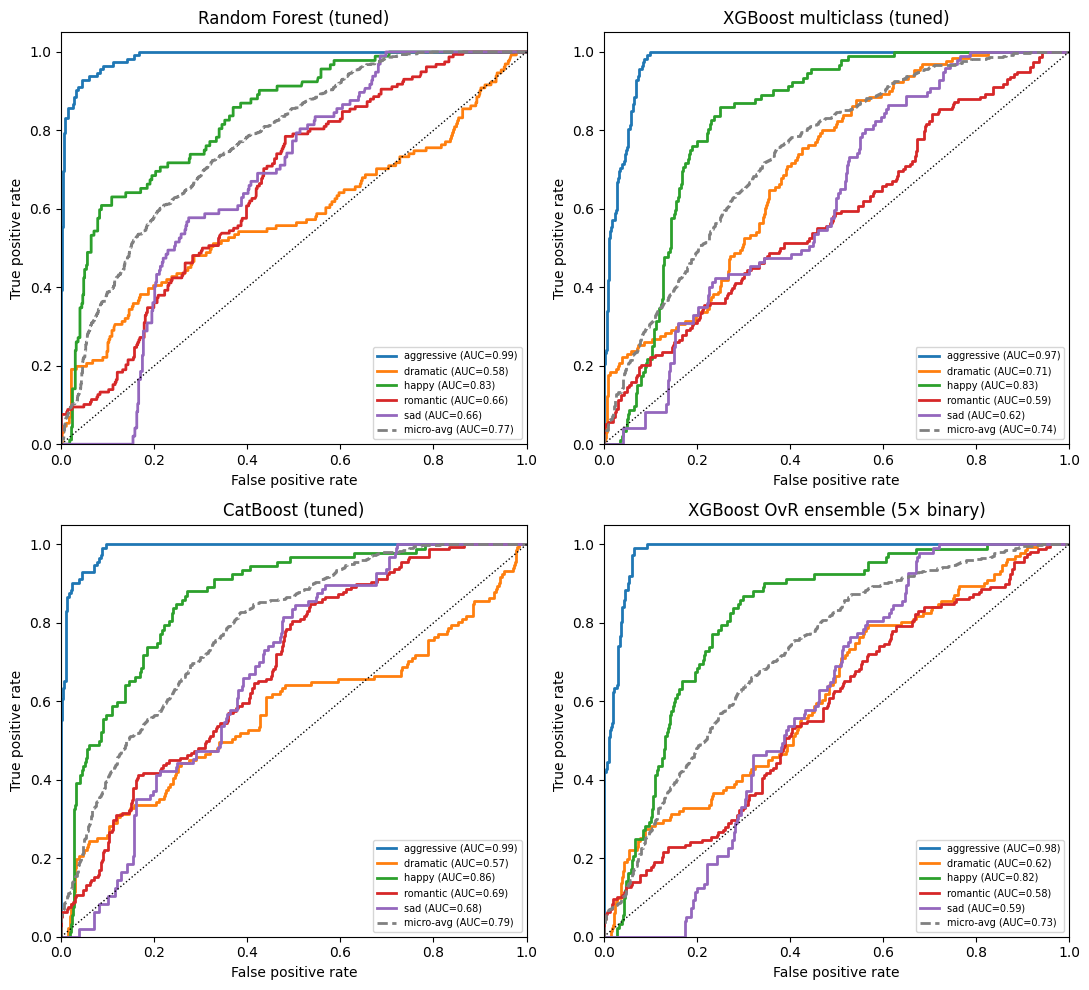

In [16]:
# ----- Multiclass ROC (one-vs-rest) on the reference test set -----

y_test_bin = label_binarize(y_ref_te, classes=np.arange(n_classes))


def plot_multiclass_roc(y_score, title, ax):
    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])
    fpr["micro"], tpr["micro"], _ = roc_curve(y_test_bin.ravel(), y_score.ravel())
    roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])
    for i, cname in enumerate(class_names):
        ax.plot(fpr[i], tpr[i], lw=2, label=f"{cname} (AUC={roc_auc[i]:.2f})")
    ax.plot(fpr["micro"], tpr["micro"], linestyle="--", color="gray", lw=2, label=f"micro-avg (AUC={roc_auc['micro']:.2f})")
    ax.plot([0, 1], [0, 1], "k:", lw=1)
    ax.set_xlim(0.0, 1.0)
    ax.set_ylim(0.0, 1.05)
    ax.set_xlabel("False positive rate")
    ax.set_ylabel("True positive rate")
    ax.set_title(title)
    ax.legend(fontsize=7, loc="lower right")


fig, axes = plt.subplots(2, 2, figsize=(11, 10))
plot_multiclass_roc(rf_ref.predict_proba(X_ref_te), "Random Forest (tuned)", axes[0, 0])
plot_multiclass_roc(xgb_ref.predict_proba(X_ref_te), "XGBoost multiclass (tuned)", axes[0, 1])
if CatBoostClassifier is not None:
    plot_multiclass_roc(cb_ref.predict_proba(X_ref_te), "CatBoost (tuned)", axes[1, 0])
else:
    axes[1, 0].set_visible(False)
plot_multiclass_roc(P_ovr, "XGBoost OvR ensemble (5× binary)", axes[1, 1])
plt.tight_layout()
plt.show()


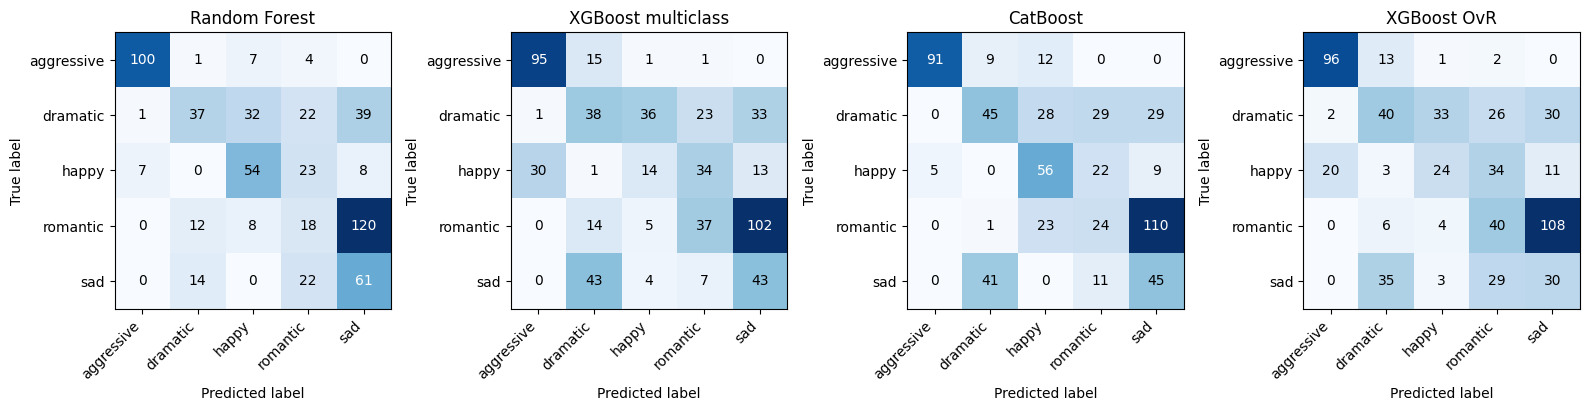

In [17]:
# ----- 5 × 5 confusion matrices on the reference split -----


def plot_confusion(y_true, y_pred, title, ax):
    cm = confusion_matrix(y_true, y_pred, labels=np.arange(n_classes))
    ax.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues)
    ax.set_title(title)
    tick_marks = np.arange(len(class_names))
    ax.set_xticks(tick_marks)
    ax.set_yticks(tick_marks)
    ax.set_xticklabels(class_names, rotation=45, ha="right")
    ax.set_yticklabels(class_names)
    ax.set_ylabel("True label")
    ax.set_xlabel("Predicted label")
    thresh = cm.max() / 2.0 if cm.max() > 0 else 0.5
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, format(cm[i, j], "d"), ha="center", va="center", color="white" if cm[i, j] > thresh else "black")


fig, axes = plt.subplots(1, 3 if CatBoostClassifier is None else 4, figsize=(4 * (3 if CatBoostClassifier is None else 4), 4))
axes = np.atleast_1d(axes)
idx = 0
plot_confusion(y_ref_te, rf_ref.predict(X_ref_te), "Random Forest", axes[idx])
idx += 1
plot_confusion(y_ref_te, xgb_ref.predict(X_ref_te), "XGBoost multiclass", axes[idx])
idx += 1
if CatBoostClassifier is not None:
    plot_confusion(y_ref_te, cb_ref.predict(X_ref_te), "CatBoost", axes[idx])
    idx += 1
plot_confusion(y_ref_te, y_ovr_pred, "XGBoost OvR", axes[idx])
plt.tight_layout()
plt.show()


## Deep learning: U-Net–style encoder–decoder on mel spectrograms

Each clip is padded to a common time length and viewed as a **2D map** (time × mel bins). A compact **U-Net** (contracting path, bottleneck, expanding path with **skip connections**) uses **(2,1) pooling** so the mel dimension is preserved for stable skip concatenation; only the time axis is downsampled. A global pool and softmax head perform **5-way mood classification**. **R2U-Net** (recurrent residual U-Net) would replace each conv block with recurrent residual blocks in the same skeleton; it is a natural next step if you need more capacity.


In [18]:
# Train / test for deep learning only (separate variables from tabular pipeline)
# IMPORTANT: group-aware split to avoid overlap leakage.
DL_SEEDS = (42, 2025)
dl_histories = []
dl_eval_scores = []

for dl_seed in DL_SEEDS:
    splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=int(dl_seed))
    tr_idx, te_idx = next(splitter.split(np.zeros(len(mel_specs)), y_mel, groups=groups_mel))

    X_tr_m = [mel_specs[i] for i in tr_idx]
    X_te_m = [mel_specs[i] for i in te_idx]
    y_tr_m = y_mel[tr_idx]
    y_te_m = y_mel[te_idx]

    max_time = int(max(s.shape[0] for s in X_tr_m))
    max_time = int(np.ceil(max_time / 4) * 4)  # align time axis for two (2,1) poolings

    def pad_list(lst):
        return pad_sequences(lst, maxlen=max_time, padding="post", dtype="float32", truncating="post")

    Xtr = pad_list(X_tr_m)[..., np.newaxis]
    Xte = pad_list(X_te_m)[..., np.newaxis]
    input_shape = (max_time, N_MELS, 1)

    def conv_block(x, filters):
        x = Conv2D(filters, (3, 3), padding="same")(x)
        x = BatchNormalization()(x)
        x = Activation("relu")(x)
        x = Conv2D(filters, (3, 3), padding="same")(x)
        x = BatchNormalization()(x)
        x = Activation("relu")(x)
        return x

    def build_unet_classifier(input_shape, num_classes, base=32):
        inp = Input(shape=input_shape)
        c1 = conv_block(inp, base)
        p1 = MaxPooling2D((2, 1))(c1)
        c2 = conv_block(p1, base * 2)
        p2 = MaxPooling2D((2, 1))(c2)
        c3 = conv_block(p2, base * 4)
        u2 = UpSampling2D((2, 1))(c3)
        u2 = Concatenate()([u2, c2])
        c_up2 = conv_block(u2, base * 2)
        u1 = UpSampling2D((2, 1))(c_up2)
        u1 = Concatenate()([u1, c1])
        c_up1 = conv_block(u1, base)
        gap = GlobalAveragePooling2D()(c_up1)
        gap = Dropout(0.25)(gap)
        out = Dense(num_classes, activation="softmax")(gap)
        return Model(inp, out)

    tf.keras.utils.set_random_seed(dl_seed)
    unet_clf = build_unet_classifier(input_shape, n_classes, base=32)
    unet_clf.compile(
        optimizer=tf.keras.optimizers.Adam(1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    hist = unet_clf.fit(
        Xtr,
        y_tr_m,
        validation_data=(Xte, y_te_m),
        epochs=25,
        batch_size=16,
        verbose=1,
    )
    loss, acc = unet_clf.evaluate(Xte, y_te_m, verbose=0)
    dl_histories.append(hist)
    dl_eval_scores.append(acc)
    print(f"DL seed {dl_seed}: test accuracy = {acc:.4f}")

dl_eval_scores = np.asarray(dl_eval_scores, dtype=np.float64)
print(
    f"U-Net–style classifier: mean test acc over DL_SEEDS = {dl_eval_scores.mean():.4f}, "
    f"std = {dl_eval_scores.std(ddof=1) if len(dl_eval_scores) > 1 else 0.0:.4f}"
)


Epoch 1/25
120/120 ━━━━━━━━━━━━━━━━━━━━ 126s 663ms/step - accuracy: 0.4890 - loss: 1.2560 - val_accuracy: 0.2288 - val_loss: 1.6853
Epoch 2/25
120/120 ━━━━━━━━━━━━━━━━━━━━ 44s 368ms/step - accuracy: 0.5738 - loss: 1.0819 - val_accuracy: 0.2881 - val_loss: 2.6454
Epoch 3/25
120/120 ━━━━━━━━━━━━━━━━━━━━ 43s 361ms/step - accuracy: 0.6099 - loss: 1.0019 - val_accuracy: 0.3203 - val_loss: 1.9267
Epoch 4/25
120/120 ━━━━━━━━━━━━━━━━━━━━ 44s 365ms/step - accuracy: 0.6466 - loss: 0.9203 - val_accuracy: 0.3322 - val_loss: 3.7514
Epoch 5/25
120/120 ━━━━━━━━━━━━━━━━━━━━ 44s 364ms/step - accuracy: 0.6660 - loss: 0.8669 - val_accuracy: 0.5407 - val_loss: 1.3932
Epoch 6/25
120/120 ━━━━━━━━━━━━━━━━━━━━ 44s 365ms/step - accuracy: 0.7099 - loss: 0.7857 - val_accuracy: 0.3576 - val_loss: 3.1630
Epoch 7/25
120/120 ━━━━━━━━━━━━━━━━━━━━ 44s 364ms/step - accuracy: 0.7136 - loss: 0.7612 - val_accuracy: 0.3797 - val_loss: 1.8692
Epoch 8/25
120/120 ━━━━━━━━━━━━━━━━━━━━ 44s 365ms/step - accuracy: 0.7393 - loss: 